In [1]:
try:
    import h2o
except:
    !pip install -qq -U h2o
    import h2o

from h2o import H2OFrame
from h2o.automl import H2OAutoML

print("h2o version:", h2o.__version__)

h2o version: 3.46.0.11


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
# import shap

## -- Functional Tools --
import itertools
from tqdm import tqdm
from time import time, sleep

## -- Machine Learning --
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, log_loss, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize, TargetEncoder as skTE

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --

PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submission = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submission = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID     = "id"
TARGET = 'Will_Buy_EV'

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = cat_cols + num_cols

train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET]  = orig[TARGET].map({'No': 0, 'Yes': 1})

FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

orig = orig[FEATURES+[TARGET]]
print("Total Features:", len(FEATURES))

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(num_cols)}")
print(f"Total Cats: {len(cat_cols)}")
print(f"Total base: {len(base_cols)}")

Total Features: 13
Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 14)

Total Nums: 7
Total Cats: 6
Total base: 13


In [6]:
for c in num_cols:
    orig[c] = orig[c].fillna(orig[c].median())

print(orig.isna().sum())

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


In [7]:
n_unique = train[base_cols].nunique().sort_values()
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
City_Type                          3
Gender                             3
Range_Anxiety_Level                3
Current_Car_Type                   4
Number_of_Cars_Owned               4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

In [8]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

print('- Helper functions ready -')

- Helper functions ready -


## FEATURE ENGINEERING

In [9]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f"TE_{col}_{agg_func}"
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [10]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")
        
    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [11]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["mean", "count"]

# train, orig_cols = original_TE(
#     orig,
#     train,
#     features=base_cols,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = original_TE(
#     orig,
#     test,
#     features=base_cols,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [12]:
# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(int).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train, INDI_COLS = appy_nan_indicator(train)
# test, _  = appy_nan_indicator(test)
# orig, _  = appy_nan_indicator(orig)

# # ## -- Fill categorical --
# # train[cat_cols] = train[cat_cols].fillna('missing')
# # test[cat_cols]  = test[cat_cols].fillna('missing')
# # orig[cat_cols]  = orig[cat_cols].fillna('missing')

# print(INDI_COLS)
# train

In [13]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Features before:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
nums_to_cats = []
for c in num_cols:
    n = f"{c}_cat"
    combined[n] = combined[c].factorize()[0]
    # combined[n] = combined[n].astype('category')
    nums_to_cats.append(n)
FEATURES = list(set(FEATURES + nums_to_cats))
## ------------------------------------------------------------
## -- Factorize all cat_cols --
for c in cat_cols:
    combined[c] = combined[c].factorize()[0]
    combined[c] = combined[c].astype(str).astype('category')
print("Label encoding complete!")
## ------------------------------------------------------------

train = combined.iloc[:len(train)]
test  = combined.iloc[len(train):len(train)+len(test)].drop(columns=[TARGET])
orig  = combined.iloc[-len(orig):]

del combined
print("Features after:", len(FEATURES))

train

Features before: 13
Label encoding complete!
Features after: 20


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat
0,0.0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0
1,1.0,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.0,1,1,1,1,1,1,1
2,2.0,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.0,2,2,2,1,2,2,2
3,3.0,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.0,0,3,3,0,3,3,3
4,4.0,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.0,3,4,4,1,1,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660.0,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.0,39,6094,382,0,12,19,2
668661,668661.0,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.0,15,160,1,0,12,18,0
668662,668662.0,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.0,37,2836,129,1,12,19,0
668663,668663.0,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.0,13,9197,289,0,7,15,0


In [14]:
## -- Frequency encoding --
freq_cols = []
select_freq = [c for c in base_cols if train[c].nunique() > 2]

print(f"\nCreating frequencies... ", end="")
for col in select_freq:
    freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True)
    n = f"{col}_freq"
    print(n+", ", end="")
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).astype("float32")
    freq_cols.append(n)

num_cols = list(set(num_cols + freq_cols))
FEATURES = list(set(FEATURES + freq_cols))

print(f"\n✓ Total frequency features: {len(freq_cols)}")

train


Creating frequencies... Gender_freq, City_Type_freq, Current_Car_Type_freq, Range_Anxiety_Level_freq, Age_freq, Annual_Income_USD_freq, Daily_Commute_km_freq, Number_of_Cars_Owned_freq, Charging_Stations_Near_Home_freq, Charging_Stations_Near_Work_freq, Environmental_Concern_Level_freq, 
✓ Total frequency features: 11


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Gender_freq,City_Type_freq,Current_Car_Type_freq,Range_Anxiety_Level_freq,Age_freq,Annual_Income_USD_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Charging_Stations_Near_Home_freq,Charging_Stations_Near_Work_freq,Environmental_Concern_Level_freq
0,0.0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0.549919,0.381892,0.453406,0.902918,0.022186,0.000155,0.001026,0.445669,0.088095,0.067974,0.220272
1,1.0,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.0,1,1,1,1,1,1,1,0.549919,0.185211,0.368530,0.902918,0.020055,0.091623,0.214171,0.429860,0.151410,0.074268,0.195583
2,2.0,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.0,2,2,2,1,2,2,2,0.441958,0.432897,0.453406,0.902918,0.022349,0.000063,0.002884,0.429860,0.031185,0.024469,0.191392
3,3.0,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.0,0,3,3,0,3,3,3,0.549919,0.381892,0.119209,0.902918,0.022186,0.000261,0.000950,0.445669,0.083074,0.074324,0.190627
4,4.0,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.0,3,4,4,1,1,4,3,0.549919,0.381892,0.119209,0.902918,0.026152,0.000431,0.001025,0.429860,0.151410,0.119510,0.190627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660.0,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.0,39,6094,382,0,12,19,2,0.549919,0.432897,0.453406,0.093570,0.021350,0.000122,0.002208,0.445669,0.079372,0.073403,0.191392
668661,668661.0,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.0,15,160,1,0,12,18,0,0.441958,0.381892,0.368530,0.902918,0.022184,0.000121,0.214171,0.445669,0.079372,0.068099,0.220272
668662,668662.0,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.0,37,2836,129,1,12,19,0,0.441958,0.381892,0.119209,0.902918,0.021320,0.000254,0.002618,0.429860,0.079372,0.073403,0.220272
668663,668663.0,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.0,13,9197,289,0,7,15,0,0.441958,0.185211,0.368530,0.902918,0.019390,0.000003,0.002653,0.445669,0.104697,0.038502,0.220272


In [15]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test, orig])

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"]

for col in cols_select:
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype(str).astype('category')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][FEATURES+digits_cols+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES+digits_cols]
orig  = combined.iloc[-len(orig):][FEATURES+digits_cols+[TARGET]]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

# update digit cols for keep
digits_cols = [i for i in set(digits_cols) if i not in set(drop_cols)]

# drop constant features
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)
orig  = orig.drop(columns=drop_cols)

# num_cols = list(set(num_cols + digits_cols))
# cat_cols = list(set(cat_cols + digits_cols))

print(f"Total digit features: {len(digits_cols)}\n")
del combined

train

Total digit features: 9



,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Gender_freq,City_Type_freq,Current_Car_Type_freq,Range_Anxiety_Level_freq,Age_freq,Annual_Income_USD_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Charging_Stations_Near_Home_freq,Charging_Stations_Near_Work_freq,Environmental_Concern_Level_freq,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.549919,0.381892,0.453406,0.902918,0.022186,0.000155,0.001026,0.445669,0.088095,0.067974,0.220272,7,8,8,2,4,3,2,6,6,0.0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,1,1,1,1,1,1,1,0.549919,0.185211,0.368530,0.902918,0.020055,0.091623,0.214171,0.429860,0.151410,0.074268,0.195583,0,0,0,0,0,5,0,8,3,0.0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,2,2,2,1,2,2,2,0.441958,0.432897,0.453406,0.902918,0.022349,0.000063,0.002884,0.429860,0.031185,0.024469,0.191392,9,8,3,4,8,6,3,6,2,1.0
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0,3,3,0,3,3,3,0.549919,0.381892,0.119209,0.902918,0.022186,0.000261,0.000950,0.445669,0.083074,0.074324,0.190627,0,8,5,3,7,3,2,6,6,0.0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,3,4,4,1,1,4,3,0.549919,0.381892,0.119209,0.902918,0.026152,0.000431,0.001025,0.429860,0.151410,0.119510,0.190627,8,9,8,7,8,0,5,4,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,39,6094,382,0,12,19,2,0.549919,0.432897,0.453406,0.093570,0.021350,0.000122,0.002208,0.445669,0.079372,0.073403,0.191392,0,9,0,1,4,7,2,0,3,0.0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,15,160,1,0,12,18,0,0.441958,0.381892,0.368530,0.902918,0.022184,0.000121,0.214171,0.445669,0.079372,0.068099,0.220272,0,9,9,9,0,5,0,2,3,0.0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,37,2836,129,1,12,19,0,0.441958,0.381892,0.119209,0.902918,0.021320,0.000254,0.002618,0.429860,0.079372,0.073403,0.220272,1,9,7,1,2,4,2,4,6,0.0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,13,9197,289,0,7,15,0,0.441958,0.185211,0.368530,0.902918,0.019390,0.000003,0.002653,0.445669,0.104697,0.038502,0.220272,3,2,9,5,7,3,4,1,5,0.0


In [16]:
# INTER = []

# combo_2_list = list(itertools.combinations(digits_cols, 2)) #  + cat_cols
# for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
#     n_col = f"Bi_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # combo_3_list = list(itertools.combinations(digits_cols, 3))
# # for c1, c2, c3 in tqdm(combo_3_list, desc='Triplewise'):
# #     n_col = f"Tri_{c1}_{c2}_{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # combo_2_1toMany = list(itertools.product(cat_cols, digits_cols))
# # for c1, c2 in tqdm(combo_2_1toMany, desc='One-to-Many'):
# #     n_col = f"Bi2_{c1}_{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# gc.collect()

In [17]:
def feat_eng(df1, trn=True):
    df = df1.copy()
    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')

    df['Income_//_10_cat'] = (df['Annual_Income_USD'] // 10).astype('float32')
    df['Income_//_100_cat'] = (df['Annual_Income_USD'] // 100).astype('float32')
    df['Income_//_1000_cat'] = (df['Annual_Income_USD'] // 1000).astype('float32')
    # df['gt_179k_lock'] = (df['Annual_Income_USD'] >= 179_000).astype('int8')

    # log_cols = []
    # for col in ['Annual_Income_USD', 'Daily_Commute_km']:
    #     log_name = f"_log_{col}"
    #     df[log_name] = np.log(df[col])
    #     log_cols.append(log_name)

    nm_cols = ['_Daily_Commute_km_/_Age'] # + log_cols
    ct_cols = ['Income_//_10_cat', 'Income_//_100_cat', 'Income_//_1000_cat'] #[] 

    if trn:
        return df, nm_cols, ct_cols
    else:
        return df

train, nm_cols, ct_cols = feat_eng(train)
test = feat_eng(test, trn=False)
orig = feat_eng(orig, trn=False)

num_cols = list(set(num_cols + nm_cols))
# cat_cols = list(set(cat_cols + ct_cols))

train

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Gender_freq,City_Type_freq,Current_Car_Type_freq,Range_Anxiety_Level_freq,Age_freq,Annual_Income_USD_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Charging_Stations_Near_Home_freq,Charging_Stations_Near_Work_freq,Environmental_Concern_Level_freq,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1,Will_Buy_EV,_Daily_Commute_km_/_Age,Income_//_10_cat,Income_//_100_cat,Income_//_1000_cat
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.549919,0.381892,0.453406,0.902918,0.022186,0.000155,0.001026,0.445669,0.088095,0.067974,0.220272,7,8,8,2,4,3,2,6,6,0.0,0.349254,9288.0,928.0,92.0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,1,1,1,1,1,1,1,0.549919,0.185211,0.368530,0.902918,0.020055,0.091623,0.214171,0.429860,0.151410,0.074268,0.195583,0,0,0,0,0,5,0,8,3,0.0,0.128205,3000.0,300.0,30.0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,2,2,2,1,2,2,2,0.441958,0.432897,0.453406,0.902918,0.022349,0.000063,0.002884,0.429860,0.031185,0.024469,0.191392,9,8,3,4,8,6,3,6,2,1.0,1.362963,9438.0,943.0,94.0
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0,3,3,0,3,3,3,0.549919,0.381892,0.119209,0.902918,0.022186,0.000261,0.000950,0.445669,0.083074,0.074324,0.190627,0,8,5,3,7,3,2,6,6,0.0,0.353731,7358.0,735.0,73.0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,3,4,4,1,1,4,3,0.549919,0.381892,0.119209,0.902918,0.026152,0.000431,0.001025,0.429860,0.151410,0.119510,0.190627,8,9,8,7,8,0,5,4,5,0.0,0.923636,5789.0,578.0,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,39,6094,382,0,12,19,2,0.549919,0.432897,0.453406,0.093570,0.021350,0.000122,0.002208,0.445669,0.079372,0.073403,0.191392,0,9,0,1,4,7,2,0,3,0.0,0.883871,7109.0,710.0,71.0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,15,160,1,0,12,18,0,0.441958,0.381892,0.368530,0.902918,0.022184,0.000121,0.214171,0.445669,0.079372,0.068099,0.220272,0,9,9,9,0,5,0,2,3,0.0,0.151515,12999.0,1299.0,129.0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,37,2836,129,1,12,19,0,0.441958,0.381892,0.119209,0.902918,0.021320,0.000254,0.002618,0.429860,0.079372,0.073403,0.220272,1,9,7,1,2,4,2,4,6,0.0,0.372308,12179.0,1217.0,121.0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,13,9197,289,0,7,15,0,0.441958,0.185211,0.368530,0.902918,0.019390,0.000003,0.002653,0.445669,0.104697,0.038502,0.220272,3,2,9,5,7,3,4,1,5,0.0,0.840385,11592.0,1159.0,115.0


In [18]:
_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

train

Total Features: 44


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Gender_freq,City_Type_freq,Current_Car_Type_freq,Range_Anxiety_Level_freq,Age_freq,Annual_Income_USD_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Charging_Stations_Near_Home_freq,Charging_Stations_Near_Work_freq,Environmental_Concern_Level_freq,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1,Will_Buy_EV,_Daily_Commute_km_/_Age,Income_//_10_cat,Income_//_100_cat,Income_//_1000_cat
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.549919,0.381892,0.453406,0.902918,0.022186,0.000155,0.001026,0.445669,0.088095,0.067974,0.220272,7,8,8,2,4,3,2,6,6,0.0,0.349254,9288.0,928.0,92.0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,1,1,1,1,1,1,1,0.549919,0.185211,0.368530,0.902918,0.020055,0.091623,0.214171,0.429860,0.151410,0.074268,0.195583,0,0,0,0,0,5,0,8,3,0.0,0.128205,3000.0,300.0,30.0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,2,2,2,1,2,2,2,0.441958,0.432897,0.453406,0.902918,0.022349,0.000063,0.002884,0.429860,0.031185,0.024469,0.191392,9,8,3,4,8,6,3,6,2,1.0,1.362963,9438.0,943.0,94.0
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0,3,3,0,3,3,3,0.549919,0.381892,0.119209,0.902918,0.022186,0.000261,0.000950,0.445669,0.083074,0.074324,0.190627,0,8,5,3,7,3,2,6,6,0.0,0.353731,7358.0,735.0,73.0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,3,4,4,1,1,4,3,0.549919,0.381892,0.119209,0.902918,0.026152,0.000431,0.001025,0.429860,0.151410,0.119510,0.190627,8,9,8,7,8,0,5,4,5,0.0,0.923636,5789.0,578.0,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,39,6094,382,0,12,19,2,0.549919,0.432897,0.453406,0.093570,0.021350,0.000122,0.002208,0.445669,0.079372,0.073403,0.191392,0,9,0,1,4,7,2,0,3,0.0,0.883871,7109.0,710.0,71.0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,15,160,1,0,12,18,0,0.441958,0.381892,0.368530,0.902918,0.022184,0.000121,0.214171,0.445669,0.079372,0.068099,0.220272,0,9,9,9,0,5,0,2,3,0.0,0.151515,12999.0,1299.0,129.0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,37,2836,129,1,12,19,0,0.441958,0.381892,0.119209,0.902918,0.021320,0.000254,0.002618,0.429860,0.079372,0.073403,0.220272,1,9,7,1,2,4,2,4,6,0.0,0.372308,12179.0,1217.0,121.0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,13,9197,289,0,7,15,0,0.441958,0.185211,0.368530,0.902918,0.019390,0.000003,0.002653,0.445669,0.104697,0.038502,0.220272,3,2,9,5,7,3,4,1,5,0.0,0.840385,11592.0,1159.0,115.0


In [19]:
# def h2o_flat_weights(y):
#     class_ratios = y.value_counts(normalize=True).sort_index().values
#     print(f"Class_ratios: {class_ratios}")
    
#     proportions = (1 / y.nunique()) / class_ratios
#     print(f"Proportions: {proportions}")
    
#     flat_weights = (proportions / min(proportions)).tolist()
#     print(f"Flat weights: {flat_weights}")

#     return flat_weights

# h2o_flat_weights(train[TARGET])

In [20]:
"""
Suppose you have 3 classes: Class A, Class B, Class C.

*   **Current Proportions (from your data):**
    *   Class A: 10% (0.10)
    *   Class B: 80% (0.80)
    *   Class C: 10% (0.10)

*   **Desired Proportions (what you want after sampling):**
    *   Class A: 33.3% (0.333)
    *   Class B: 33.3% (0.333)
    *   Class C: 33.3% (0.333) - *You want a balanced dataset.*

**Calculations:**

1.  **Ratio of desired to current for each class:**
    *   Class A: `0.333 / 0.10 = 3.33`
    *   Class B: `0.333 / 0.80 = 0.416`
    *   Class C: `0.333 / 0.10 = 3.33`

2.  **Normalization:** The goal is to set one of the `sample_factors` to `1.0` and adjust the others.
    A common strategy is to find the minimum of the ratios calculated above and divide all ratios by that minimum.
    This makes the smallest `sample_factor` equal to `1.0`, effectively scaling others relative to it.
    In this case, the minimum is `0.416` (for Class B).

    *   `sample_factor` for Class A: `3.33 / 0.416 = 8.00`
    *   `sample_factor` for Class B: `0.416 / 0.416 = 1.00`
    *   `sample_factor` for Class C: `3.33 / 0.416 = 8.00`
    
So, your `sample_factors` would be `[8.0, 1.0, 8.0]` if Class B is the second class in your H2O-3 frame.
"""

'\nSuppose you have 3 classes: Class A, Class B, Class C.\n\n*   **Current Proportions (from your data):**\n    *   Class A: 10% (0.10)\n    *   Class B: 80% (0.80)\n    *   Class C: 10% (0.10)\n\n*   **Desired Proportions (what you want after sampling):**\n    *   Class A: 33.3% (0.333)\n    *   Class B: 33.3% (0.333)\n    *   Class C: 33.3% (0.333) - *You want a balanced dataset.*\n\n**Calculations:**\n\n1.  **Ratio of desired to current for each class:**\n    *   Class A: `0.333 / 0.10 = 3.33`\n    *   Class B: `0.333 / 0.80 = 0.416`\n    *   Class C: `0.333 / 0.10 = 3.33`\n\n2.  **Normalization:** The goal is to set one of the `sample_factors` to `1.0` and adjust the others.\n    A common strategy is to find the minimum of the ratios calculated above and divide all ratios by that minimum.\n    This makes the smallest `sample_factor` equal to `1.0`, effectively scaling others relative to it.\n    In this case, the minimum is `0.416` (for Class B).\n\n    *   `sample_factor` for Clas

## Config | Trainer

In [21]:
# ## -- Trainer for h2o.H20Frame
# def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cat_cols):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     y = train_df[target]
#     num_cls = y.nunique()

#     oof_preds = np.zeros((len(train_df), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))
#     fold_scores = []

#     oof_glm = np.zeros((len(train_df), num_cls))
#     oof_gbm = np.zeros((len(train_df), num_cls))
#     oof_drf = np.zeros((len(train_df), num_cls))
#     oof_xgb = np.zeros((len(train_df), num_cls))
#     oof_dpl = np.zeros((len(train_df), num_cls))

#     test_glm = np.zeros((len(test_df), num_cls))
#     test_gbm = np.zeros((len(test_df), num_cls))
#     test_drf = np.zeros((len(test_df), num_cls))
#     test_xgb = np.zeros((len(test_df), num_cls))
#     test_dpl = np.zeros((len(test_df), num_cls))

#     h2o_models = [
#         ("glm", oof_glm, test_glm),
#         ("gbm", oof_gbm, test_gbm),
#         ("drf", oof_drf, test_drf),
#         ("xgboost", oof_xgb, test_xgb),
#         ("deeplearning", oof_dpl, test_dpl),
#     ]
#     ## ---------------------------------------------------------------------------------
#     h2o.init(verbose=True, nthreads=os.cpu_count(), max_mem_size="20G")
    
#     test_df[TARGET] = "Null"
#     df_ = pd.concat([train_df, test_df])
#     h2o_df = H2OFrame(df_)

#     ## -- Split train set --
#     h2o_train = h2o_df[h2o_df[TARGET] != "Null"]
#     h2o_train[TARGET] = h2o_train[TARGET].asfactor()

#     ## -- Split test set --
#     h2o_test = h2o_df[h2o_df[TARGET] == "Null"]
#     # h2o_test = h2o_test.drop([TARGET])

#     for col in cat_cols:
#         h2o_train[col] = h2o_train[col].asfactor()
#         h2o_test[col]  = h2o_test[col].asfactor()
#     ## ---------------------------------------------------------------------------------

#     n_splits = kf.n_splits

#     for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], y)):
#         print(f"\n{CFG["YELLOW"]}##### FOLD {idx+1}/{n_splits} | ", end="")

#         train_idx = list(train_idx.ravel())
#         val_idx = list(val_idx.ravel())

#         X_train = h2o_train[[int(i) for i in train_idx], :]
#         X_valid = h2o_train[[int(i) for i in val_idx], :]
#         X_test  = h2o_test[:, features]

#         print(f"Train shape: {X_train.shape}{CFG["RESET"]}")

#         ## --------------------------------------------------------------------------------------
#         model = H2OAutoML(**params)
#         model.train(features, target, training_frame=X_train, validation_frame=X_valid)
#         ## --------------------------------------------------------------------------------------
#         ## -- LEADER MODEL -- 
#         oof_preds_ = model.leader.predict(X_valid).as_data_frame(use_multi_thread=True)
#         oof_preds[val_idx] = oof_preds_.iloc[:, -num_cls:].to_numpy()

#         test_preds_ = model.leader.predict(X_test).as_data_frame(use_multi_thread=True)
#         test_preds += test_preds_.iloc[:, -num_cls:].to_numpy()
#         ## --------------------------------------------------------------------------------------
#         ## -- PER MODEL BASELINE -- 
#         for (mod, x_oof, x_tst) in h2o_models:
#             print(f" ••• Predicting with {mod}")
#             algo_model = model.get_best_model(algorithm=mod)

#             if algo_model is not None:
#                 single_oof = algo_model.predict(X_valid).as_data_frame(use_multi_thread=True)
#                 x_oof[val_idx] = single_oof.iloc[:, -num_cls:].to_numpy()

#                 single_test = algo_model.predict(X_test).as_data_frame(use_multi_thread=True)
#                 x_tst += single_test.iloc[:, -num_cls:].to_numpy()
#             else:
#                 print(f"    ⚠️ Warning: No model found for {mod} in this fold.")
#         ## ---------------------------------------------------------------------------------------

#         ## -- Get fold score --
#         # Use target mapping cleanly onto validation series
#         fold_score = balanced_acc(y[val_idx].map(mapping), oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"{CFG["YELLOW"]} • Fold_{idx+1} bal_acc: {fold_score:.5f}{CFG["RESET"]}")

#     ## -- Average the test predictions outside the main fold loop
#     test_preds /= n_splits

#     ## -- FIX 3: Fixed variable unpacking for clean output messages
#     for (mod, __, x_tst) in tqdm(h2o_models, desc="Averaging model tests"):
#         print(f"• {mod}... ", end="")
#         x_tst /= n_splits

#     ## -- Print CV results
#     print("\n==================================================")
#     print(f"{n_splits}-FOLDS CV: {model_name}")
#     print("==================================================")
#     for i, score in enumerate(fold_scores):
#         print(f" • Fold {i+1} score: {score:.5f}")
    
#     ## -- Final out-of-fold --
#     overall_score = np.round(balanced_acc(y.map(mapping), oof_preds), 5)
#     print("-------------------------------------------------|")
#     print(f"OOF score: {overall_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins')

#     return {
#         "oof_preds": oof_preds,
#         "test_preds": test_preds,
#         "h2o": h2o_models,
#         "score": overall_score,
#         "model": model,
#         "val_data": X_valid, 
#     }

# print("⚙️ Trainer function ready ⚙️")

In [22]:
## -- Trainer for pandas DataFrame
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    cat_cols=None, use_te=False,
    use_weights=False, use_stack=False, use_orig=False,
):
    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    start = time()

    ## - Initialize H2O once -- 
    h2o.init(verbose=False, max_mem_size="20G") 

    # X = train_df[features]
    # y = train_df[target].astype(str)

    N_SPLITS = kfold.n_splits

    oof_preds   = np.zeros(len(train_df))
    test_preds  = np.zeros(len(test_df))
    fold_scores = []

    if use_orig:
        # "mean", "count", "std", "median", "skew", "nunique", "max", "min"
        orig_aggs = ["mean"]
        train_df, orig_cols = original_TE(
            orig,
            train_df,
            features=base_cols,
            target=TARGET,
            aggs=orig_aggs,
            # fill_nan=True,
        )
        X = train_df[features+orig_cols]
        y = train_df[target].astype("int8")

        test_df, _ = original_TE(
            orig,
            test_df,
            features=base_cols,
            target=TARGET,
            aggs=orig_aggs,
            # fill_nan=True,
        )
        test_df = test_df[features+orig_cols]
    else:
        X = train_df[features]
        y = train_df[target].astype("int8")
    
    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n{"="*90}")
        print(f"+++++ FOLD {idx}/{N_SPLITS}", end=" | ")
        
        X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
        X_test = test_df.copy()

        # ## -- OPTION: Concatenate original data --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)

        if use_weights:
            print("Using weights ✓")
            def h2o_flat_weights(y):
                class_ratios = y.value_counts(normalize=True).sort_index().values
                print(f"Class_ratios: {class_ratios}")
                proportions = (1 / y.nunique()) / class_ratios
                print(f"Proportions: {proportions}")
                flat_weights = (proportions / min(proportions)).tolist()
                print(f"Flat weights: {flat_weights}")
                return flat_weights

            params['balance_classes'] = True
            params['class_sampling_factors'] = h2o_flat_weights(y_train)

        ## -- TE Opt1. -> Using CUSTOM --
        if use_te:
            te_cols = nums_to_cats + ct_cols #+ INTER
            print(f"Target Encoding {len(te_cols)} features...", end=" | ")
            TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train = TE.fit_transform(X_train, y_train)
            X_valid = TE.transform(X_valid)
            X_test  = TE.transform(X_test)
        else:
            te_cols = []

        te_features = [c for c in X_train.columns if c.startswith('TE_')]

        print(f"shape: {X_train.shape} | apply_TE: {use_te}")

        # Prepare frames
        h2o_X_frame = H2OFrame(pd.concat([X_train, y_train], axis=1))
        h2o_V_frame = H2OFrame(pd.concat([X_valid, y_valid], axis=1))
        h2o_valid   = H2OFrame(X_valid)
        h2o_test    = H2OFrame(X_test)

        # Recognize target as a factor column
        h2o_X_frame[target] = h2o_X_frame[target].asfactor()
        h2o_V_frame[target] = h2o_V_frame[target].asfactor()

        for col in cat_cols+digits_cols:
            h2o_X_frame[col] = h2o_X_frame[col].asfactor()
            h2o_V_frame[col] = h2o_V_frame[col].asfactor()
            h2o_valid[col]   = h2o_valid[col].asfactor()
            h2o_test[col]    = h2o_test[col].asfactor()

        print(f"⚙️ H2O_Frame shape: {h2o_X_frame.shape}\n")
        ## -------------------------------------------------------------------------------------
        
        model = H2OAutoML(**params)
        model.train(
            y = target,
            training_frame = h2o_X_frame,
            validation_frame = None if use_stack else h2o_V_frame,
        )
        # --------------------------------------------------------------------------------------
        # Leader Model -- 
        oof_predictions = model.leader.predict(h2o_valid).as_data_frame(use_multi_thread=True)
        oof_preds[val_idx] = oof_predictions.iloc[:, -1].to_numpy()

        test_predictions = model.leader.predict(h2o_test)
        display(test_predictions[:5, :])
        test_preds += test_predictions.as_data_frame(use_multi_thread=True).iloc[:, -1].to_numpy() / N_SPLITS
        # --------------------------------------------------------------------------------------

        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)

        print(f"{CFG['YELLOW']} • FOLD {idx} AUC: {fold_score:.6f}{CFG['RESET']}")
        
    ## -------------------------------------------------------------------------
    # ## -- Fixed variable unpacking for clean output messages
    # for (mod, __, x_tst) in tqdm(h2o_models, desc="Averaging model tests"):
    #     print(f"• {mod}... ", end="")
    #     x_tst /= N_SPLITS

    ## -- Average test predictions
    # test_preds /= N_SPLITS
    ## -------------------------------------------------------------------------

    ## -- CV results --
    print("\n==================================================")
    print(f"{N_SPLITS}-FOLD CV: {model_name} | {h2o_X_frame.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s:.6f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start)/60):.2f} mins')

    return {
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "score": oof_score,
        "model": model,
        "val_data": h2o_V_frame, 
        # "h2o": h2o_models,
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [23]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]

FOLDS = 10
USE_FULL_TRAIN = True

skf = StratifiedKFold(n_splits=FOLDS , shuffle=True, random_state=42)

x_sample, x_sample2 = train_test_split(train, stratify=train[TARGET], train_size=100_000, random_state=9)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Number_of_Cars_Owned_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Gender_freq,City_Type_freq,Current_Car_Type_freq,Range_Anxiety_Level_freq,Age_freq,Annual_Income_USD_freq,Daily_Commute_km_freq,Number_of_Cars_Owned_freq,Charging_Stations_Near_Home_freq,Charging_Stations_Near_Work_freq,Environmental_Concern_Level_freq,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Age_digit0,Age_digit1,Will_Buy_EV,_Daily_Commute_km_/_Age,Income_//_10_cat,Income_//_100_cat,Income_//_1000_cat
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.549919,0.381892,0.453406,0.902918,0.022186,0.000155,0.001026,0.445669,0.088095,0.067974,0.220272,7,8,8,2,4,3,2,6,6,0.0,0.349254,9288.0,928.0,92.0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,1,1,1,1,1,1,1,0.549919,0.185211,0.368530,0.902918,0.020055,0.091623,0.214171,0.429860,0.151410,0.074268,0.195583,0,0,0,0,0,5,0,8,3,0.0,0.128205,3000.0,300.0,30.0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,2,2,2,1,2,2,2,0.441958,0.432897,0.453406,0.902918,0.022349,0.000063,0.002884,0.429860,0.031185,0.024469,0.191392,9,8,3,4,8,6,3,6,2,1.0,1.362963,9438.0,943.0,94.0
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0,3,3,0,3,3,3,0.549919,0.381892,0.119209,0.902918,0.022186,0.000261,0.000950,0.445669,0.083074,0.074324,0.190627,0,8,5,3,7,3,2,6,6,0.0,0.353731,7358.0,735.0,73.0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,3,4,4,1,1,4,3,0.549919,0.381892,0.119209,0.902918,0.026152,0.000431,0.001025,0.429860,0.151410,0.119510,0.190627,8,9,8,7,8,0,5,4,5,0.0,0.923636,5789.0,578.0,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,39,6094,382,0,12,19,2,0.549919,0.432897,0.453406,0.093570,0.021350,0.000122,0.002208,0.445669,0.079372,0.073403,0.191392,0,9,0,1,4,7,2,0,3,0.0,0.883871,7109.0,710.0,71.0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,15,160,1,0,12,18,0,0.441958,0.381892,0.368530,0.902918,0.022184,0.000121,0.214171,0.445669,0.079372,0.068099,0.220272,0,9,9,9,0,5,0,2,3,0.0,0.151515,12999.0,1299.0,129.0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,37,2836,129,1,12,19,0,0.441958,0.381892,0.119209,0.902918,0.021320,0.000254,0.002618,0.429860,0.079372,0.073403,0.220272,1,9,7,1,2,4,2,4,6,0.0,0.372308,12179.0,1217.0,121.0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,13,9197,289,0,7,15,0,0.441958,0.185211,0.368530,0.902918,0.019390,0.000003,0.002653,0.445669,0.104697,0.038502,0.220272,3,2,9,5,7,3,4,1,5,0.0,0.840385,11592.0,1159.0,115.0


In [24]:
for idx, (t_idx, v_idx) in enumerate(skf.split(train_X[FEATURES], train_X[TARGET])):
    print(f"FOLD {idx+1}/{skf.n_splits} {'-'*25}")
    print(f"  train: {[int(i) for i in t_idx][25:30]}")
    print(f"  valid: {[int(i) for i in v_idx][25:30]}")

FOLD 1/10 -------------------------
  train: [30, 32, 33, 34, 35]
  valid: [259, 260, 307, 310, 325]
FOLD 2/10 -------------------------
  train: [31, 32, 33, 34, 35]
  valid: [236, 240, 243, 256, 262]
FOLD 3/10 -------------------------
  train: [27, 29, 30, 31, 33]
  valid: [187, 192, 211, 221, 227]
FOLD 4/10 -------------------------
  train: [28, 29, 30, 31, 32]
  valid: [280, 284, 314, 320, 322]
FOLD 5/10 -------------------------
  train: [27, 28, 29, 30, 31]
  valid: [315, 334, 340, 343, 345]
FOLD 6/10 -------------------------
  train: [28, 29, 30, 31, 32]
  valid: [304, 317, 323, 328, 335]
FOLD 7/10 -------------------------
  train: [27, 28, 30, 31, 32]
  valid: [212, 216, 224, 238, 246]
FOLD 8/10 -------------------------
  train: [29, 31, 32, 33, 34]
  valid: [215, 218, 219, 229, 239]
FOLD 9/10 -------------------------
  train: [26, 27, 28, 29, 30]
  valid: [295, 308, 309, 312, 319]
FOLD 10/10 -------------------------
  train: [25, 26, 27, 28, 29]
  valid: [344, 348, 398,

In [25]:
# !rm -r /kaggle/working/ 

In [26]:
# if all_predictions:
#     all_predictions.clear()

KAGGLE_TIME = 40000

h_params = {
    'max_models': 40,
    'max_runtime_secs': KAGGLE_TIME//FOLDS, #60*5, # 8000
    # 'max_runtime_secs_per_model': 300,
    # 'nfolds': 4, # 0 if validation_frame is provided, def=-1
    'stopping_rounds': 5,
    'stopping_metric': "AUC",
    # "preprocessing": ['target_encoding'],
    'seed': 101,
}

for VALUE in [True]: #, False
    n = "H2Ostack" if VALUE else "H2Obest"
    h_params["nfolds"] = 3 if VALUE else 0
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=h_params,
        train_df=train_X,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        cat_cols=cat_cols,
        use_stack=VALUE, 
        use_orig=True,
        use_te=True,
        # use_weights=True,
    )


===== Starting CV: H2Ostack | CPU: 4 =====
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


Original augment complete!: 100%|██████████| 13/13 [00:00<00:00, 20.11it/s]



+++++ FOLD 1/10 | Target Encoding 10 features... | shape: (601798, 57) | apply_TE: True
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
⚙️ H2O_Frame shape: (601798, 58)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


predict,p0,p1
0,0.98062,0.01938
0,0.987666,0.0123339
0,0.996041,0.00395854
0,0.997837,0.00216254
0,0.984239,0.0157614


Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
 • FOLD 1 AUC: 0.944320

+++++ FOLD 2/10 | Target Encoding 10 features... | shape: (601798, 57) | apply_TE: True
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
⚙️ H2O_Frame shape: (601798, 58)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100

...

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
 • FOLD 8 AUC: 0.946129

+++++ FOLD 9/10 | Target Encoding 10 features... | shape: (601799, 57) | apply_TE: True
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
⚙️ H2O_Frame shape: (601799, 58)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100

predict,p0,p1
0,0.976509,0.0234912
0,0.980742,0.0192584
0,0.996815,0.00318524
0,0.998292,0.0017078
0,0.980517,0.0194834


Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
 • FOLD 9 AUC: 0.946432

+++++ FOLD 10/10 | Target Encoding 10 features... | shape: (601799, 57) | apply_TE: True
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
⚙️ H2O_Frame shape: (601799, 58)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
xgboost prediction progress: |███████████████████████████████████████████████████| (done) 10

predict,p0,p1
0,0.979131,0.0208689
0,0.986779,0.013221
0,0.994605,0.00539529
0,0.998357,0.00164344
0,0.974404,0.0255956


Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
 • FOLD 10 AUC: 0.944454

10-FOLD CV: H2Ostack | (601799, 58)
 • Fold 1 AUC: 0.944320
 • Fold 2 AUC: 0.944387
 • Fold 3 AUC: 0.944683
 • Fold 4 AUC: 0.945298
 • Fold 5 AUC: 0.946002
 • Fold 6 AUC: 0.946406
 • Fold 7 AUC: 0.945349
 • Fold 8 AUC: 0.946129
 • Fold 9 AUC: 0.946432
 • Fold 10 AUC: 0.944454
-------------------------------------------------|
OOF score: 0.945339
AVG score: 0.945346 ± 0.000810
-------------------------------------------------|
682.96 mins


In [27]:
# base + TE(nums_to_cats) + freq_cols + digits + feat_eng() ##+ TE(INTER[digits])
# ==================================================
# 3-FOLD CV: H2Ostack | (66667, 58)
# ==================================================
#  • Fold 1 AUC: 0.942382
#  • Fold 2 AUC: 0.943009
#  • Fold 3 AUC: 0.942127
# -------------------------------------------------|
# OOF score: 0.942489 
# AVG score: 0.942506 ± 0.000371
# -------------------------------------------------|
# 17.39 mins

# base + orig_cols(mean) + TE(nums_to_cats) + freq_cols + digits + feat_eng() ##+ TE(INTER[digits])
# ==================================================
# 3-FOLD CV: H2Obest | (66667, 58)
# ==================================================
#  • Fold 1 AUC: 0.942388
#  • Fold 2 AUC: 0.943009
#  • Fold 3 AUC: 0.942127
# -------------------------------------------------|
# OOF score: 0.942495
# AVG score: 0.942508 ± 0.000370
# -------------------------------------------------|
# 14.74 mins

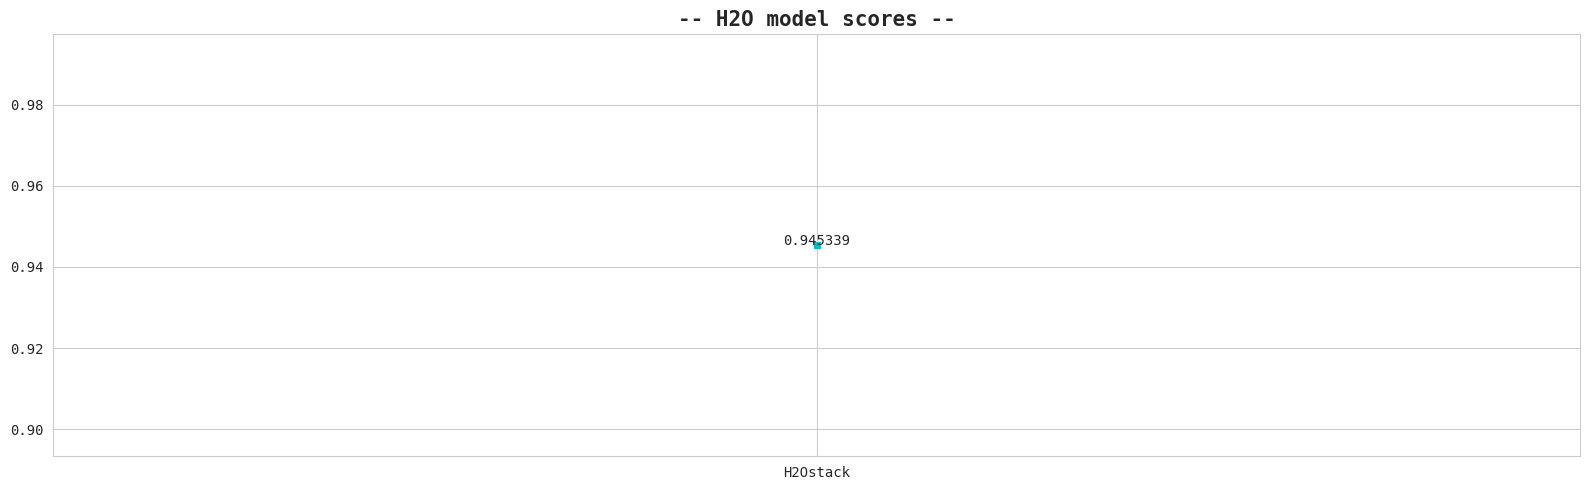

In [28]:
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax1 = sns.lineplot([*all_scores.values()], marker="s")

_add = 1e-6

for i, s in enumerate([*all_scores.values()]):
    ax1.text(float(i), s+_add, s, ha="center", va="baseline")

# plt.ylim((0.96, 0.97))
# plt.legend(loc="best")
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title("-- H2O model scores --", fontdict={"weight": "semibold", "size": 15})

plt.tight_layout() 
plt.show()

H2Ostack_945339 saved!


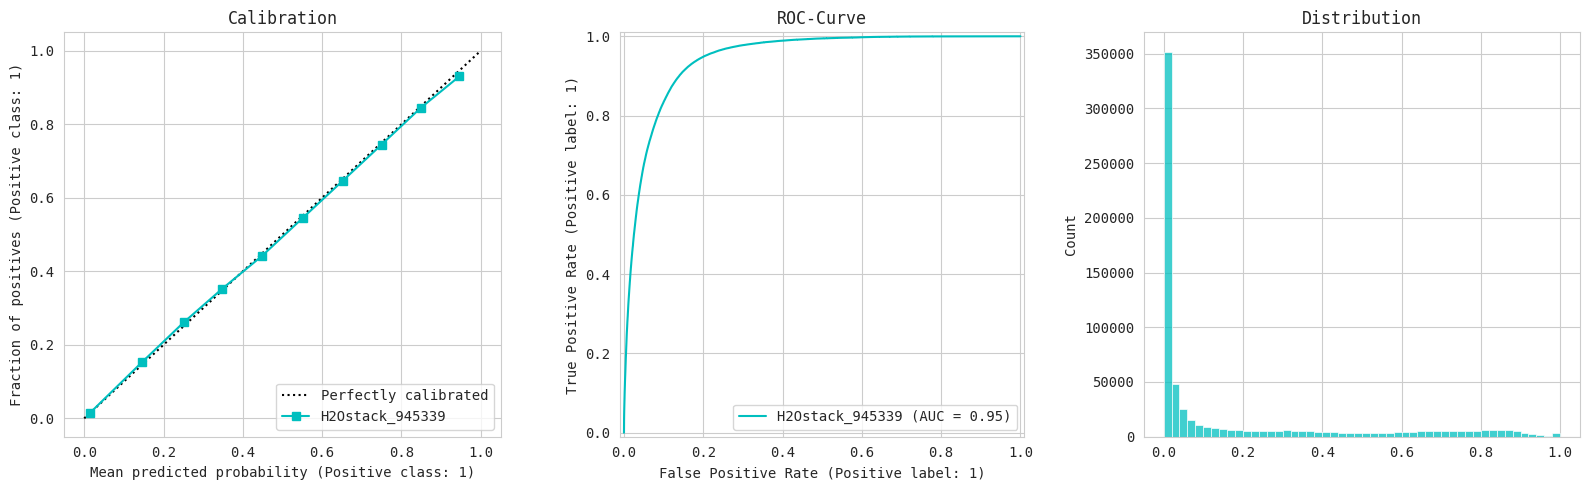

In [29]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_X[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title("Calibration")

            RocCurveDisplay.from_predictions(train_X[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title("ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title("Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [30]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submission[TARGET] = y
            submission.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n:>17} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

  H2Ostack_945339 saved! (286571,)



,H2Ostack_
0,0.021539
1,0.015094
2,0.004532
3,0.002221
4,0.025941
...,...
286566,0.000376
286567,0.334602
286568,0.000680
286569,0.000434


# XAI

In [31]:
## -- Inspect model -- 
model_list = list(all_predictions.keys())
model_list

['H2Ostack']

In [32]:
get_model = all_predictions[model_list[0]]
get_model["model"].leader

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_3_AutoML_10_20260930_45555


Model Summary: 
    number_of_trees
--  -----------------
    55

ModelMetricsBinomial: xgboost
** Reported on train data. **

MSE: 0.06762950222289284
RMSE: 0.26005672885524966
LogLoss: 0.21558263730725052
Mean Per-Class Error: 0.1406249369863325
AUC: 0.9476384725577564
AUCPR: 0.7860506831380352
Gini: 0.8952769451155127

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.35977754751619234
       0       1       Error    Rate
-----  ------  ------  -------  ------------------
0      455537  41161   0.0829   (41161.0/496698.0)
1      20850   84251   0.1984   (20850.0/105101.0)
Total  476387  125412  0.103    (62011.0/601799.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.359778     0.730987  219
max f2                       0.161684     0.814933  295
max f0point5                 0.592737     0.73688   142
max accuracy                 0.516468     0.903513  167
max precision                0.998911     1         0
max recall                   0.000352407  1         399
max specificity              0.998911     1         0
max absolute_mcc             0.33722      0.672127  228
max min_per_class_accuracy   0.25035      0.879478  262
max mean_per_class_accuracy  0.175034     0.883372  290
max tns                      0.998911     496698    0
max fns                      0.998911     103904    0
max fps                      0.000352407  496698    399
max tps                      0.000352407  105101    399
max tnr                      0.998911     1         0
max fnr                      0.998911     0.988611  0
max fpr                      0.000352407  1         399
max tpr                      0.000352407  1         399

Gains/Lift Table: Avg response rate: 17.46 %, avg score: 17.47 %
group    cumulative_data_fraction    lower_threshold    lift         cumulative_lift    response_rate    score        cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  -----------  -----------------  ---------------  -----------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.01                        0.916522           5.54418      5.54418            0.968262         0.960528     0.968262                    0.960528            0.0554419       0.0554419                  454.418   454.418            0.0550574
2        0.02                        0.886828           5.21593      5.38005            0.910934         0.900124     0.939598                    0.930326            0.0521594       0.107601                   421.593   438.005            0.106138
3        0.03                        0.865622           5.00375      5.25462            0.873878         0.876084     0.917691                    0.912245            0.0500376       0.157639                   400.375   425.462            0.154647
4        0.0400001                   0.84453            4.91526      5.16978            0.858425         0.855062     0.902875                    0.89795             0.0491527       0.206792                   391.526   416.978            0.202084
5        0.0500001                   0.822156           4.79728      5.09528            0.83782          0.833491     0.889864                    0.885058            0.0479729       0.254764                   379.728   409.528            0.248092
6        0.1                         0.695302           4.35675      4.72602            0.760884         0.75972      0.825374                    0.822389            0.217838        0.472603                   335.675   372.602            0.451445
7        0.15   

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_3_AutoML_10_20260930_45555,0.944456,0.221671,0.770475,0.14446,0.263455,0.0694084,89650,0.00221,XGBoost
GBM_2_AutoML_10_20260930_45555,0.944158,0.222378,0.771512,0.145388,0.263281,0.0693169,52909,0.009473,GBM
GBM_3_AutoML_10_20260930_45555,0.944067,0.222416,0.770488,0.151442,0.263421,0.0693905,60019,0.010002,GBM
GLM_1_AutoML_10_20260930_45555,0.943849,0.222697,0.770326,0.142476,0.264117,0.069758,65741,0.001345,GLM
GBM_4_AutoML_10_20260930_45555,0.943715,0.225147,0.770029,0.147779,0.264012,0.0697021,47881,0.007623,GBM
GBM_1_AutoML_10_20260930_45555,0.942462,0.226795,0.765659,0.148508,0.265264,0.0703652,79396,0.010661,GBM
XGBoost_2_AutoML_10_20260930_45555,0.941833,0.226999,0.759656,0.136234,0.266452,0.0709965,164569,0.003615,XGBoost
DRF_1_AutoML_10_20260930_45555,0.941238,0.234902,0.763049,0.147368,0.265324,0.0703967,163884,0.018844,DRF
XGBoost_1_AutoML_10_20260930_45555,0.937714,0.236913,0.744552,0.153822,0.271746,0.0738459,239520,0.004769,XGBoost


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## XGBoost_3_AutoML_10_20260930_45555

,0,1,Error,Rate
0,50500.0,4688.0,0.0849,(4688.0/55188.0)
1,2382.0,9296.0,0.204,(2382.0/11678.0)
Total,52882.0,13984.0,0.1057,(7070.0/66866.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

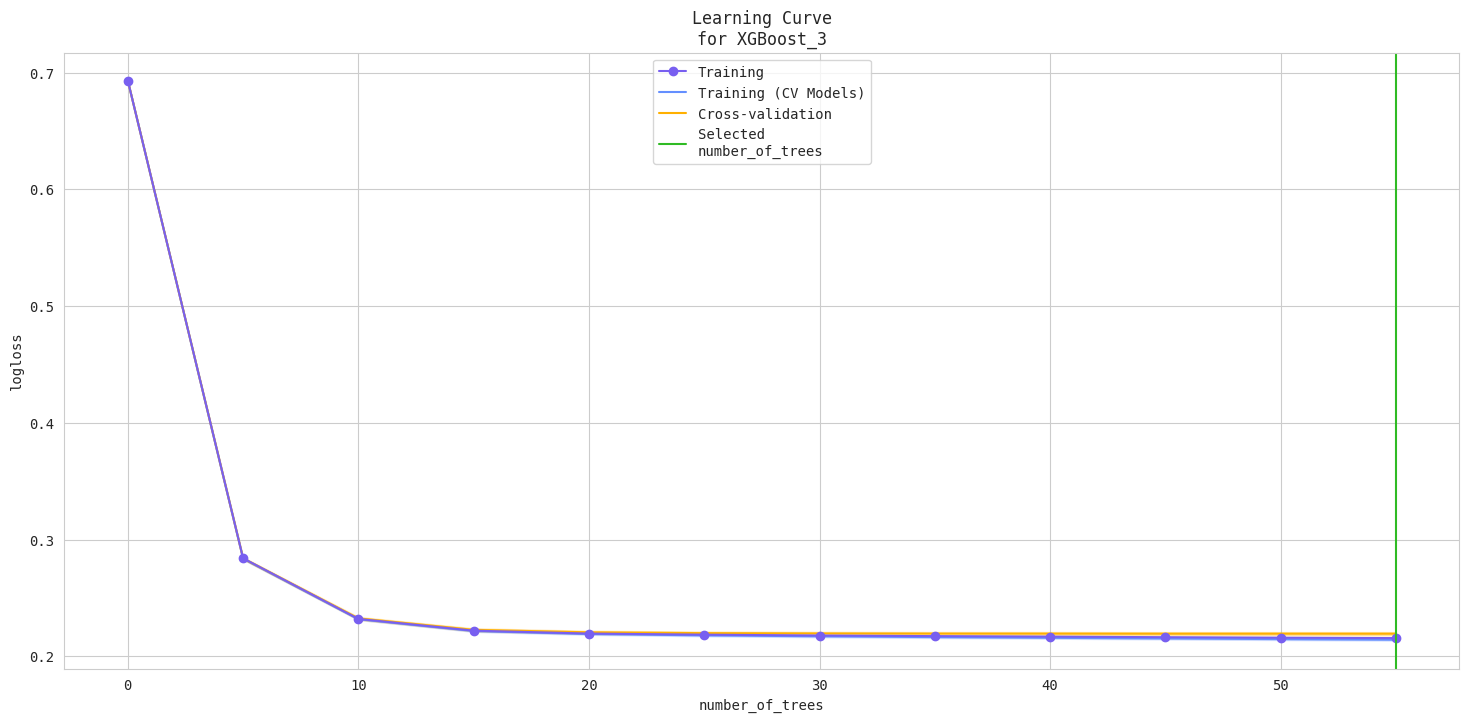

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

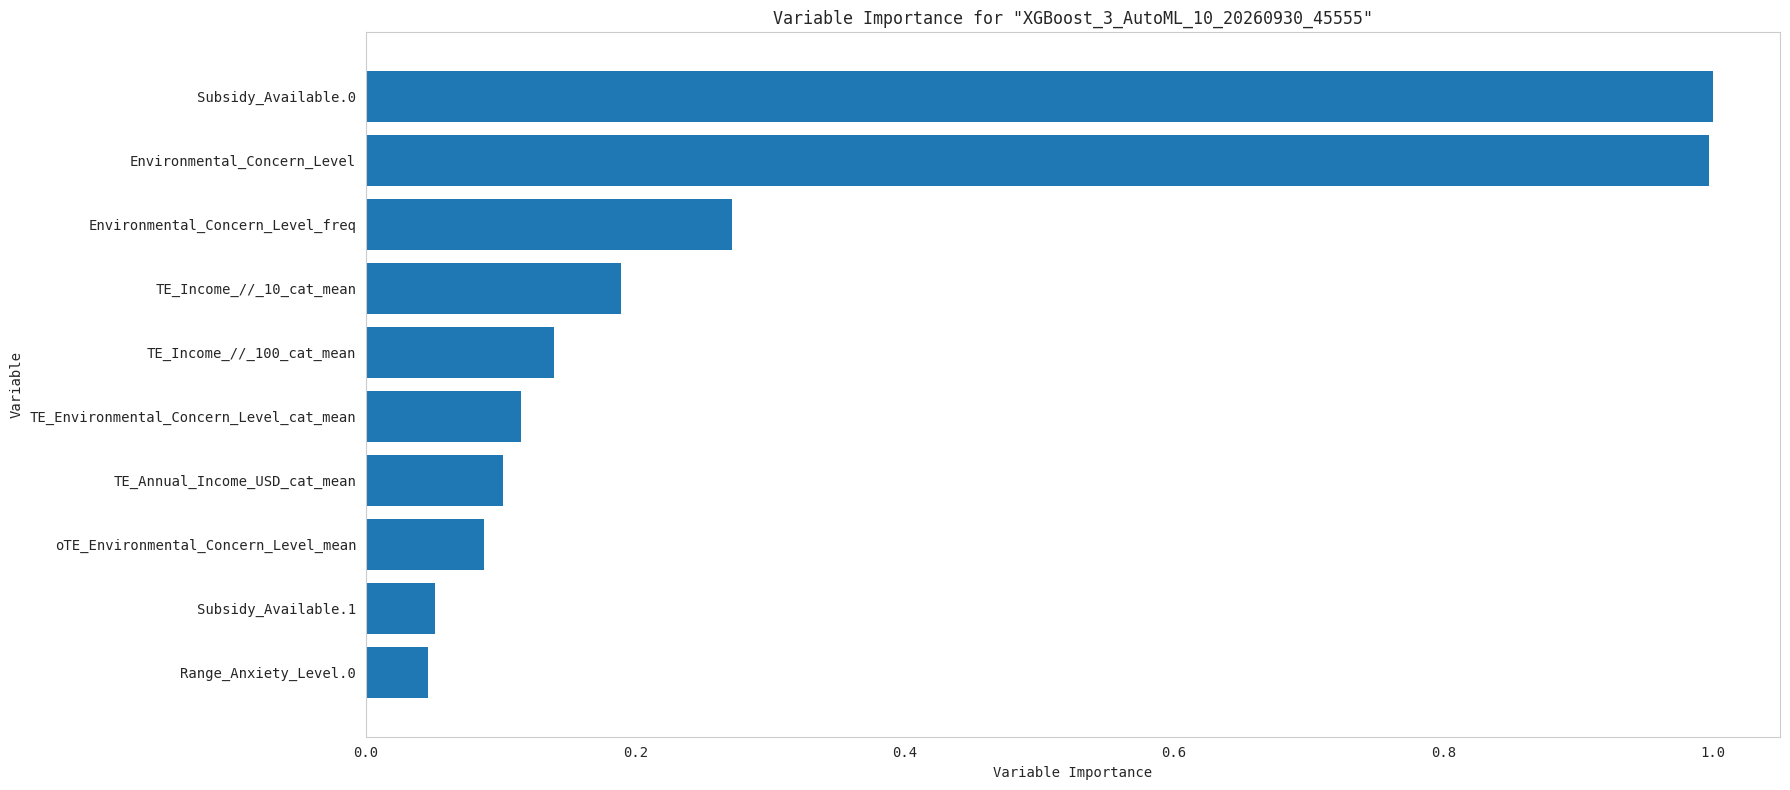

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

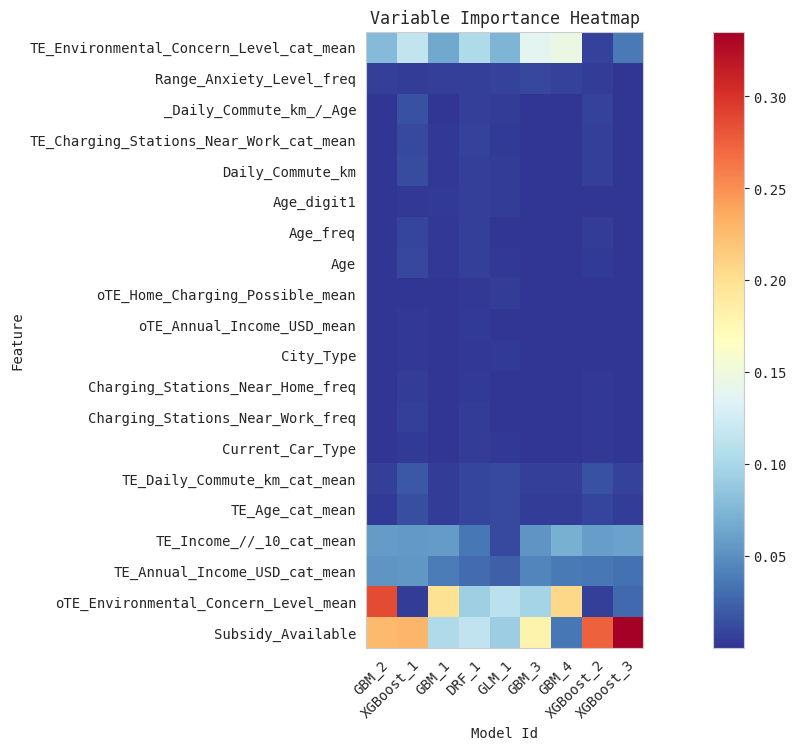

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

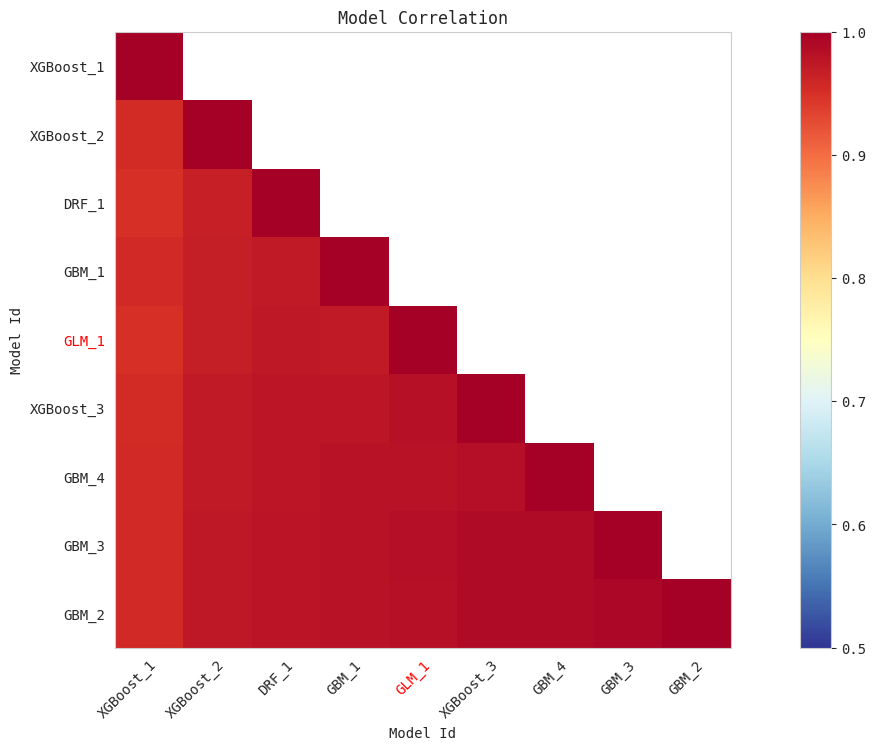

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_3_AutoML_10_20260930_45555,0.944456,0.221671,0.770475,0.14446,0.263455,0.0694084,89650,0.00221,XGBoost
GBM_2_AutoML_10_20260930_45555,0.944158,0.222378,0.771512,0.145388,0.263281,0.0693169,52909,0.009473,GBM
GBM_3_AutoML_10_20260930_45555,0.944067,0.222416,0.770488,0.151442,0.263421,0.0693905,60019,0.010002,GBM
GLM_1_AutoML_10_20260930_45555,0.943849,0.222697,0.770326,0.142476,0.264117,0.069758,65741,0.001345,GLM
GBM_4_AutoML_10_20260930_45555,0.943715,0.225147,0.770029,0.147779,0.264012,0.0697021,47881,0.007623,GBM
GBM_1_AutoML_10_20260930_45555,0.942462,0.226795,0.765659,0.148508,0.265264,0.0703652,79396,0.010661,GBM
XGBoost_2_AutoML_10_20260930_45555,0.941833,0.226999,0.759656,0.136234,0.266452,0.0709965,164569,0.003615,XGBoost
DRF_1_AutoML_10_20260930_45555,0.941238,0.234902,0.763049,0.147368,0.265324,0.0703967,163884,0.018844,DRF
XGBoost_1_AutoML_10_20260930_45555,0.937714,0.236913,0.744552,0.153822,0.271746,0.0738459,239520,0.004769,XGBoost


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## XGBoost_3_AutoML_10_20260930_45555

,0,1,Error,Rate
0,50500.0,4688.0,0.0849,(4688.0/55188.0)
1,2382.0,9296.0,0.204,(2382.0/11678.0)
Total,52882.0,13984.0,0.1057,(7070.0/66866.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

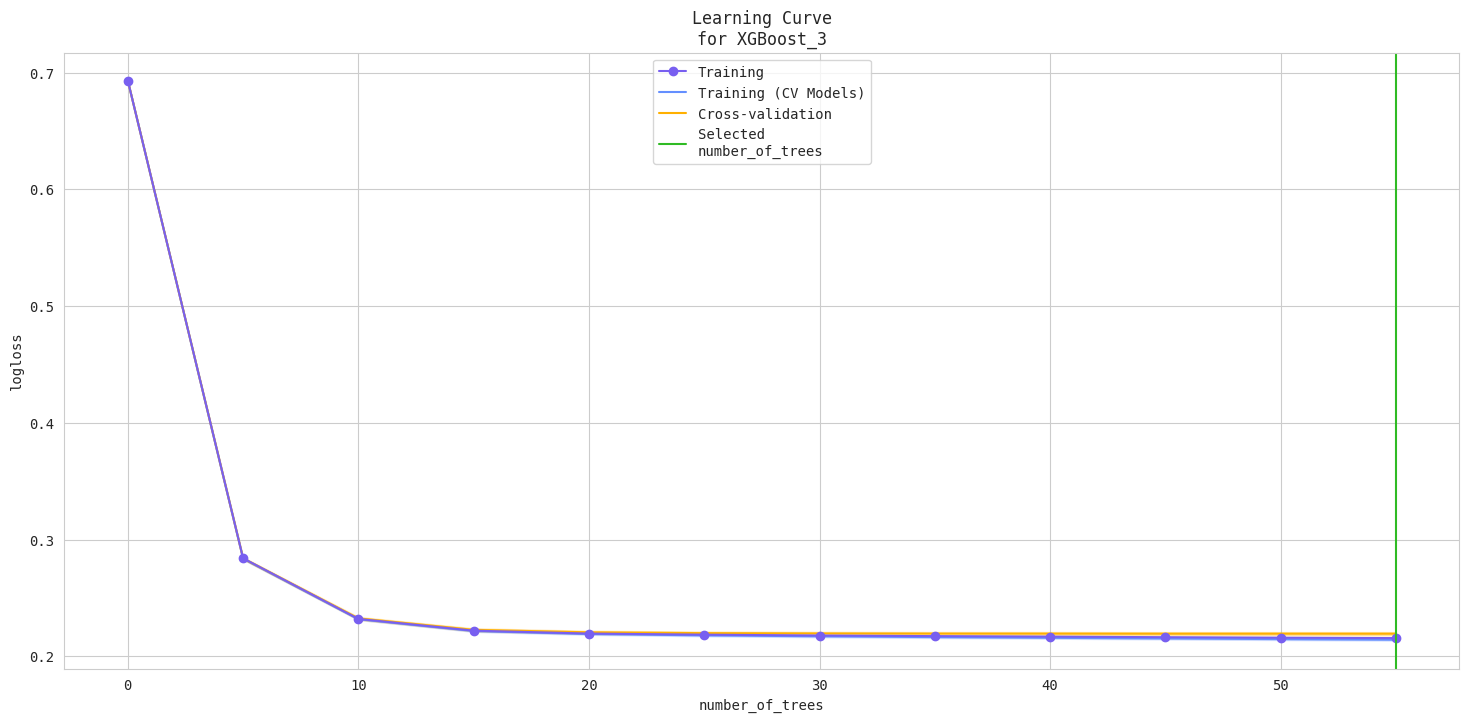

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

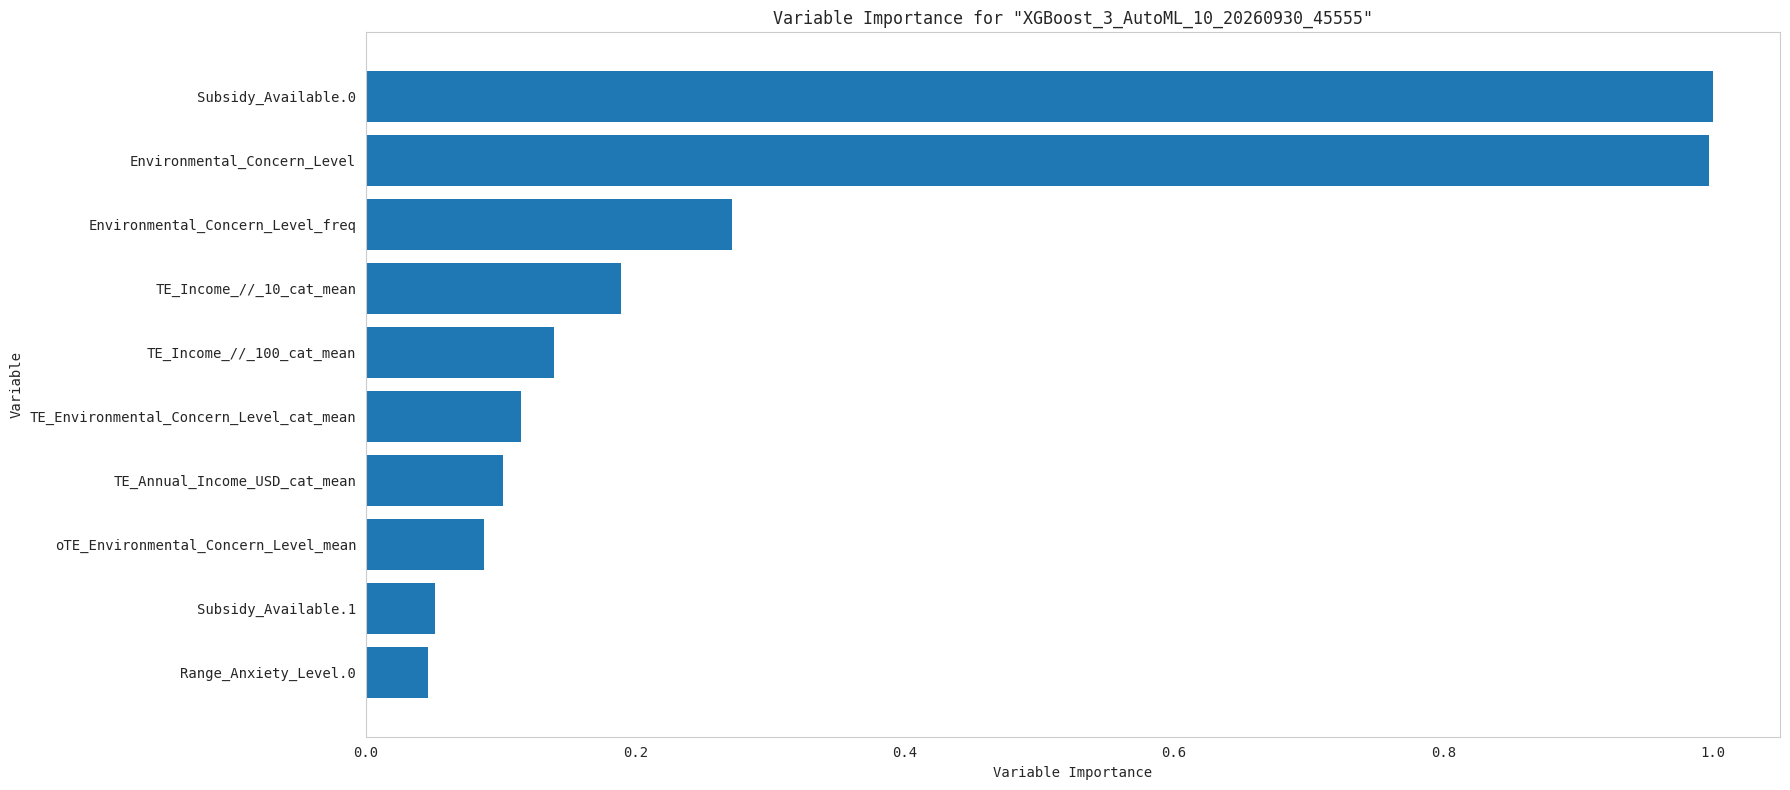

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

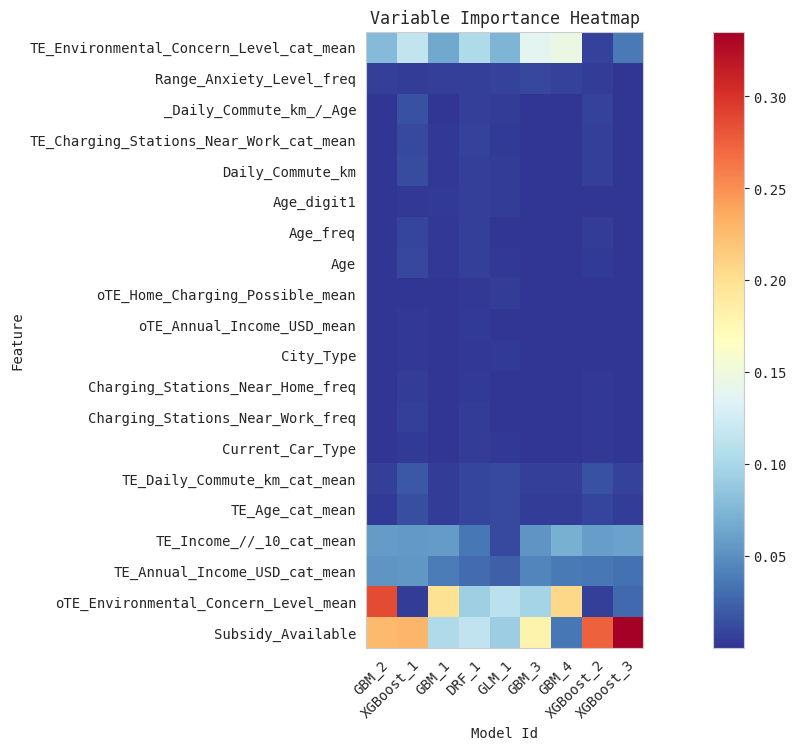

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

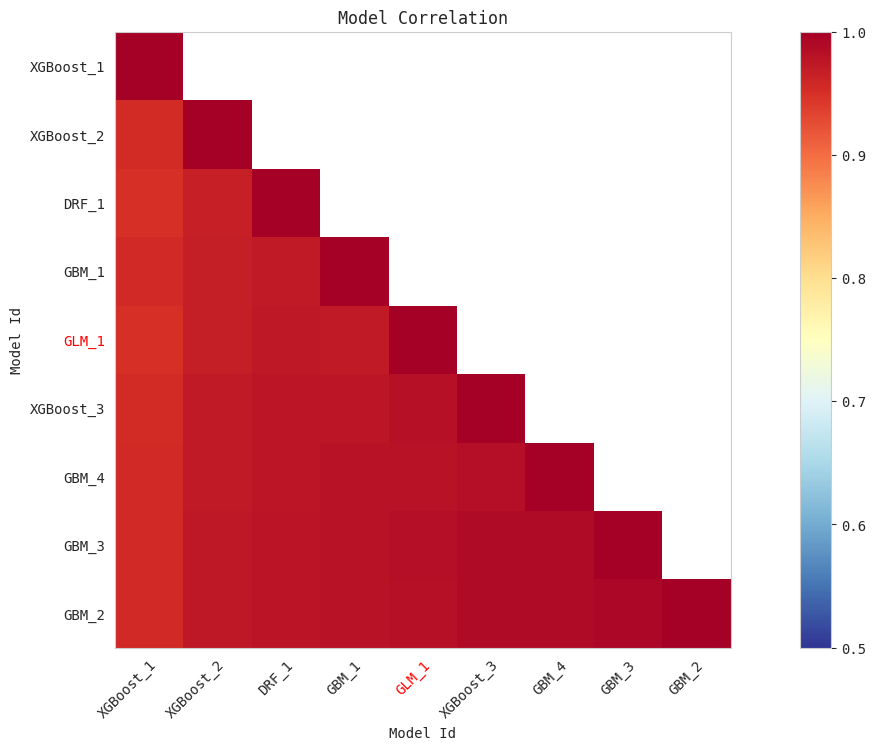

In [33]:
h2o.explain(
    get_model['model'], get_model['val_data'],
    exclude_explanations=[
        "pdp",
        "shap_summary", # Issues with shap display
    ],
    top_n_features=3,
    figsize=(18, 8),
)

In [34]:
h2o.cluster().shutdown()

In [35]:
# !rm -r /kaggle/working/ 

# HILLCLIMB

In [36]:
# try:
#     from hillclimbers import climb_hill, partial
# except:
#     %pip install -q -U hillclimbers
#     from hillclimbers import climb_hill, partial

In [37]:
def dataloader(filepath, train_prefix, test_prefix):    
    # Store dataframes in lists
    train_list = []
    test_list  = []

    print('Loading .npy files: ')
    for (root, dirs, files) in os.walk(filepath):
        # Filter files first to ensure accurate tqdm count
        npy_files = [f for f in sorted(files) if f.endswith('.npy')]
        
        for file in tqdm(npy_files):
            arr = np.load(os.path.join(root, file))
            base_name = file.replace('.npy', '')
            
            # Create the 3-column chunk
            new_cols = pd.DataFrame(
                arr, 
                columns=[f"{base_name}_c{c}" for c in range(3)]
            )
            
            if train_prefix in file:
                train_list.append(new_cols)
            elif test_prefix in file:
                test_list.append(new_cols)
    
    # Concatenate everything at once
    train_df = pd.concat(train_list, axis=1) if train_list else pd.DataFrame()
    test_df  = pd.concat(test_list, axis=1) if test_list else pd.DataFrame()

    train_df.columns = [c.replace('oof_', '') for c in train_df.columns]
    test_df.columns  = [c.replace('test_', '') for c in test_df.columns]
    
    return train_df, test_df, train_list

def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols

    return df_renamed
    
print('Data loader function ready!')

Data loader function ready!


In [38]:
# OOF_PATH = "/kaggle/working/"
# oof_df, test_df, col_names = dataloader(OOF_PATH, "oof", "test")

# per_model_class_output = []
# desc = 'Extracting class names'

# for model in tqdm(col_names, total=len(col_names), desc=desc):
#     model.columns = [c.replace("oof_", "") for c in model.columns]
#     per_model_class_output.append(model.columns.tolist())

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if "best" in c: #
#         oof_df.drop(columns=[c],  inplace=True)
#         test_df.drop(columns=[c], inplace=True)

# print("-"*50)
# ## -- Check for missingness --
# print(f"OOF  Null: {oof_df.isna().sum().sum()} | ",end="")
# print(f"TEST Null: {test_df.isna().sum().sum()}")
# print("-"*50)

# ## -- Apply column rename function --
# oof_df  = rename_duplicate_cols(oof_df)
# test_df = rename_duplicate_cols(test_df)

# print()
# print(f"{CFG['YELLOW']} • Columns updated: {oof_df.shape[1]}")

# display(oof_df.head(3))
# print()
# display(test_df.head(3))

In [39]:
# %%time

# trn = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
# pred_hc, oof_hc = climb_hill(
#                                train = train_X,
#                               target = TARGET,
#                          oof_pred_df = oof_df,
#                         test_pred_df = test_df,
#                            objective = "maximize",
#                          eval_metric = partial(roc_auc_score),
#                     # negative_weights = True,
#                     return_oof_preds = True,
#                            precision = 0.01,
#                            plot_hill = True,
#                            plot_hist = True,
# )

In [40]:
# hc_score = str(round(roc_auc_score(train_X[TARGET], oof_hc), 5)).split('.')[1]
# print(f"Hillclimb score: {hc_score}")

# np.save(f"oof_{VERS}_hillclimb_{hc_score}_.npy", oof_hc)
# np.save(f"test_{VERS}_hillclimb_{hc_score}_.npy", pred_hc)

# submit[TARGET] = pred_hc
# submit.to_csv(f"submit_{VERS}_hillclimb_{hc_score}.csv", index=False)
# print(f"\n✅ Saved hillclimb ensemble!")

# submit.head(10)